# Интерактивные гео-карты, создание признаков и кластеризация - Анализируем погоду вместе!

Этот ноутбук содержит готовые блоки для:
- интерактивных гео-карт с Plotly
- создания признаков для почасовых погодных данных
- кластеризации данных

Предполагается, что у тебя уже есть DataFrame `df` с погодным минимумом:
- `lat`, `lon`
- `temperature`
- `precipitation`
- `timestamp`
- `location_id`

Если какой-то колонки нет, подстрой блок под свою структуру данных.


## Блок 0. Базовые импорты

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# 1. Интерактивные гео-карты с Plotly

Ниже — отдельные блоки для разных типов интерактивных карт.


## Блок 1. Импорт Plotly

In [31]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Искусственный датафрейм
from datetime import datetime, timedelta

def create_test_weather_data(
    n_locations: int = 5,
    n_days: int = 30,
    start_date: str = "2024-01-01",
    random_seed: int = 42
) -> pd.DataFrame:
    """
    Создает искусственный датафрейм с погодными данными для тестирования
    
    Параметры:
    ----------
    n_locations : int
        Количество уникальных локаций
    n_days : int
        Количество дней данных
    start_date : str
        Начальная дата в формате 'YYYY-MM-DD'
    random_seed : int
        Seed для воспроизводимости
    
    Возвращает:
    -----------
    pd.DataFrame
        Тестовый датафрейм с колонками:
        - location_id: идентификатор локации
        - lat, lon: координаты
        - timestamp: временная метка (почасово)
        - temperature: температура (℃)
        - precipitation: осадки (мм)
    """
    np.random.seed(random_seed)
    
    # Создаем базовые локации с реальными координатами (примеры городов России)
    locations_data = {
        0: {"lat": 55.7558, "lon": 37.6173, "name": "Moscow", "temp_base": 5, "temp_amp": 10},
        1: {"lat": 59.9343, "lon": 30.3351, "name": "Saint Petersburg", "temp_base": 4, "temp_amp": 8},
        2: {"lat": 55.0415, "lon": 82.9346, "name": "Novosibirsk", "temp_base": 0, "temp_amp": 12},
        3: {"lat": 56.8389, "lon": 60.6057, "name": "Yekaterinburg", "temp_base": 1, "temp_amp": 11},
        4: {"lat": 43.6028, "lon": 39.7342, "name": "Sochi", "temp_base": 10, "temp_amp": 6}
    }
    
    # Ограничиваем количеством локаций
    locations_data = {i: locations_data[i] for i in range(min(n_locations, len(locations_data)))}
    
    # Создаем временной ряд (почасово)
    start = pd.to_datetime(start_date)
    timestamps = pd.date_range(
        start=start,
        periods=n_days * 24,
        freq='h'
    )
    
    data = []
    
    for loc_id, loc_info in locations_data.items():
        for ts in timestamps:
            # Базовая температура с суточным циклом
            hour = ts.hour
            day_of_year = ts.dayofyear
            
            # Суточный цикл: максимальная температура днем, минимальная ночью
            daily_cycle = 5 * np.sin(2 * np.pi * (hour - 14) / 24)
            
            # Годовой цикл: максимальная температура летом
            yearly_cycle = 8 * np.sin(2 * np.pi * (day_of_year - 180) / 365)
            
            # Базовая температура + циклы + шум
            temp_base = loc_info["temp_base"]
            temp_amp = loc_info["temp_amp"]
            
            temperature = (
                temp_base 
                + yearly_cycle 
                + daily_cycle 
                + np.random.normal(0, 1.5)  # случайный шум
            )
            
            # Осадки: вероятность и интенсивность зависят от температуры
            precip_prob = 0.3 if temperature < 0 else 0.2
            has_precip = np.random.random() < precip_prob
            
            if has_precip:
                if temperature < 0:
                    precipitation = np.random.exponential(0.5)  # снег
                else:
                    precipitation = np.random.exponential(2)  # дождь
            else:
                precipitation = 0
            
            data.append({
                "location_id": loc_id,
                "lat": loc_info["lat"],
                "lon": loc_info["lon"],
                "timestamp": ts,
                "temperature": round(temperature, 1),
                "precipitation": round(precipitation, 2)
            })
    
    df = pd.DataFrame(data)
    
    # Добавляем немного пропусков для реалистичности (опционально)
    # mask = np.random.random(len(df)) < 0.01
    # df.loc[mask, "temperature"] = np.nan
    
    print(f"✅ Создан тестовый датасет:")
    print(f"   - Локаций: {df['location_id'].nunique()}")
    print(f"   - Временных точек: {df['timestamp'].nunique()}")
    print(f"   - Всего записей: {len(df)}")
    print(f"   - Диапазон дат: {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"   - Температура: {df['temperature'].min():.1f}°C → {df['temperature'].max():.1f}°C")
    print(f"   - Осадки: макс {df['precipitation'].max():.2f} мм")
    
    return df

# Создаем тестовый датафрейм
df = create_test_weather_data(
    n_locations=3,      # можно изменить: 3, 5 или больше
    n_days=14,          # 14 дней данных
    start_date="2024-01-15"
)

# Быстрый просмотр
print("\nПервые 10 строк:")
display(df.head(10))

print("\nИнформация о датафрейме:")
df.info()

print("\nСтатистика по температурам по локациям:")
display(df.groupby("location_id")["temperature"].describe().round(2))

✅ Создан тестовый датасет:
   - Локаций: 3
   - Временных точек: 336
   - Всего записей: 1008
   - Диапазон дат: 2024-01-15 00:00:00 → 2024-01-28 23:00:00
   - Температура: -12.0°C → 10.7°C
   - Осадки: макс 11.54 мм

Первые 10 строк:


,location_id,lat,lon,timestamp,temperature,precipitation
0,0,55.7558,37.6173,2024-01-15 00:00:00,5.9,0.00
1,0,55.7558,37.6173,2024-01-15 01:00:00,3.7,0.00
2,0,55.7558,37.6173,2024-01-15 02:00:00,2.3,4.02
3,0,55.7558,37.6173,2024-01-15 03:00:00,1.0,0.00
4,0,55.7558,37.6173,2024-01-15 04:00:00,-0.7,0.18
5,0,55.7558,37.6173,2024-01-15 05:00:00,-1.7,0.00
6,0,55.7558,37.6173,2024-01-15 06:00:00,-4.3,0.00
7,0,55.7558,37.6173,2024-01-15 07:00:00,-3.0,0.17
8,0,55.7558,37.6173,2024-01-15 08:00:00,-3.4,0.00
9,0,55.7558,37.6173,2024-01-15 09:00:00,-5.4,0.36



Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   location_id    1008 non-null   int64         
 1   lat            1008 non-null   float64       
 2   lon            1008 non-null   float64       
 3   timestamp      1008 non-null   datetime64[ns]
 4   temperature    1008 non-null   float64       
 5   precipitation  1008 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.4 KB

Статистика по температурам по локациям:


,count,mean,std,min,25%,50%,75%,max
location_id,,,,,,,,
0,336.0,1.87,3.85,-7.7,-1.30,1.6,5.10,10.7
1,336.0,0.86,3.75,-7.4,-2.40,0.7,4.10,9.5
2,336.0,-3.14,3.84,-12.0,-6.43,-2.9,0.32,4.8


## Блок 2. Базовая интерактивная карта точек

Подходит, если есть `lat`, `lon` и, например, температура или осадки.


In [ ]:
fig = px.scatter_map(
    df,
    lat="lat",
    lon="lon",
    color="temperature",
    size="precipitation",
    hover_name=None,
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()
fig.write_html("base_map.html", include_plotlyjs='cdn')

## Блок 3. Карта с цветом по категории

Например, по погодному классу или кластеру.


In [34]:
'''
fig = px.scatter_map(
    df,
    lat="lat",
    lon="lon",
    color="cluster",
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()'''

'\nfig = px.scatter_map(\n    df,\n    lat="lat",\n    lon="lon",\n    color="cluster",\n    hover_data=["temperature", "precipitation"],\n    zoom=4,\n    height=600\n)\n\nfig.update_layout(mapbox_style="open-street-map")\nfig.show()'

## Блок 4. Анимация по времени

Если есть временной столбец, можно смотреть динамику по часам или дням.


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Для анимации удобно округлить или привести к строке
df["time_step"] = df["timestamp"].dt.strftime("%Y-%m-%d %H:00")

fig = px.scatter_map(
    df,
    lat="lat",
    lon="lon",
    color="temperature",
    size="precipitation",
    animation_frame="time_step",
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()
fig.write_html("time_animation.html", include_plotlyjs='cdn')

## Блок 5. Тепловая карта точек

Если нужно показать плотность или интенсивность значений.


In [ ]:
fig = px.density_map(
    df,
    lat="lat",
    lon="lon",
    z="temperature",  # можно заменить на осадки или другой числовой признак
    radius=15,
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()
fig.write_html("density.html", include_plotlyjs='cdn')

# 2. Создание признаков

Ниже блоки именно под почасовые температуры, осадки и погодные признаки.


## Блок 1. Подготовка datetime

In [37]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Если есть location_id, сортируем по локации и времени
df = df.sort_values(["location_id", "timestamp"]).reset_index(drop=True)

# Если location_id нет, используй так:
# df = df.sort_values("timestamp").reset_index(drop=True)

## Блок 2. Простые календарные признаки

In [38]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["dayofweek"] = df["timestamp"].dt.dayofweek  # 0 = понедельник
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

## Блок 3. Циклические признаки времени

Это полезнее, чем просто `hour` и `month`, потому что время циклично.


In [39]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

## Блок 4. Лаги температуры и осадков

Главное — делать по группам локаций, чтобы не было смешивания разных точек.


In [40]:
df["temp_lag_1"] = df.groupby("location_id")["temperature"].shift(1)
df["temp_lag_3"] = df.groupby("location_id")["temperature"].shift(3)
df["temp_lag_24"] = df.groupby("location_id")["temperature"].shift(24)

df["precip_lag_1"] = df.groupby("location_id")["precipitation"].shift(1)
df["precip_lag_3"] = df.groupby("location_id")["precipitation"].shift(3)
df["precip_lag_24"] = df.groupby("location_id")["precipitation"].shift(24)

## Блок 5. Скользящие статистики

In [41]:
df["temp_roll_mean_3"] = (
    df.groupby("location_id")["temperature"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["temp_roll_mean_24"] = (
    df.groupby("location_id")["temperature"]
    .transform(lambda x: x.rolling(window=24, min_periods=1).mean())
)

df["temp_roll_min_24"] = (
    df.groupby("location_id")["temperature"]
    .transform(lambda x: x.rolling(window=24, min_periods=1).min())
)

df["temp_roll_max_24"] = (
    df.groupby("location_id")["temperature"]
    .transform(lambda x: x.rolling(window=24, min_periods=1).max())
)

## Блок 6. Изменение температуры и осадков

In [42]:
df["temp_diff_1"] = df.groupby("location_id")["temperature"].diff(1)
df["precip_diff_1"] = df.groupby("location_id")["precipitation"].diff(1)

## Блок 7. Суточная амплитуда температуры

In [43]:
df["date"] = df["timestamp"].dt.date

daily_temp_stats = (
    df.groupby(["location_id", "date"])["temperature"]
    .agg(["min", "max"])
    .reset_index()
)

daily_temp_stats["temp_amplitude_day"] = daily_temp_stats["max"] - daily_temp_stats["min"]

df = df.merge(
    daily_temp_stats[["location_id", "date", "temp_amplitude_day"]],
    on=["location_id", "date"],
    how="left"
)

## Блок 8. Признаки наличия осадков

In [44]:
df["has_precipitation"] = (df["precipitation"] > 0).astype(int)

# Порог можно менять под задачу
df["heavy_precipitation"] = (df["precipitation"] > 5).astype(int)

## Блок 9. Простая агрегация по суткам

Если потом захочешь строить модель на дневном уровне.


In [45]:
daily_df = (
    df.groupby(["location_id", "date"])
    .agg(
        temp_mean=("temperature", "mean"),
        temp_min=("temperature", "min"),
        temp_max=("temperature", "max"),
        precip_sum=("precipitation", "sum"),
        precip_mean=("precipitation", "mean")
    )
    .reset_index()
)

display(daily_df.head())

,location_id,date,temp_mean,temp_min,temp_max,precip_sum,precip_mean
0,0,2024-01-15,2.237500,-5.4,8.8,10.58,0.440833
1,0,2024-01-16,2.787500,-2.6,8.9,14.12,0.588333
2,0,2024-01-17,1.837500,-4.2,8.2,8.82,0.367500
3,0,2024-01-18,2.745833,-3.7,10.7,10.69,0.445417
4,0,2024-01-19,2.191667,-4.4,7.5,4.18,0.174167


## Блок 10. Аккуратное удаление строк после feature engineering

После лагов и rolling обычно появляются `NaN` в начале ряда.
Их лучше убирать после создания признаков, а не раньше.


In [46]:
feature_cols_to_check = [
    "temp_lag_1",
    "temp_lag_24",
    "precip_lag_1"
]

df_model = df.dropna(subset=feature_cols_to_check).reset_index(drop=True)
print(df_model.shape)

(936, 32)


# 3. Кластеризация данных

Ниже — простой и понятный шаблон.


## Блок 1. Выбор признаков для кластеризации

Для кластеризации лучше брать только числовые признаки.
И не тащить туда target.


In [47]:
cluster_features = [
    "temperature",
    "precipitation",
    "lat",
    "lon",
    "hour",
    "month",
    "temp_lag_1",
    "temp_roll_mean_24",
    "temp_amplitude_day"
]

cluster_df = df_model[cluster_features].copy()
display(cluster_df.head())

,temperature,precipitation,lat,lon,hour,month,temp_lag_1,temp_roll_mean_24,temp_amplitude_day
0,5.5,8.67,55.7558,37.6173,0,1,7.7,2.220833,11.5
1,3.2,0.00,55.7558,37.6173,1,1,5.5,2.200000,11.5
2,3.4,0.00,55.7558,37.6173,2,1,3.2,2.245833,11.5
3,2.5,0.00,55.7558,37.6173,3,1,3.4,2.308333,11.5
4,-0.3,0.99,55.7558,37.6173,4,1,2.5,2.325000,11.5


## Блок 2. Заполнение пропусков и масштабирование

Для кластеризации масштабирование почти всегда нужно.


In [48]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
cluster_imputed = imputer.fit_transform(cluster_df)

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_imputed)

print(cluster_scaled.shape)

(936, 9)


## Блок 3. Подбор количества кластеров через Elbow

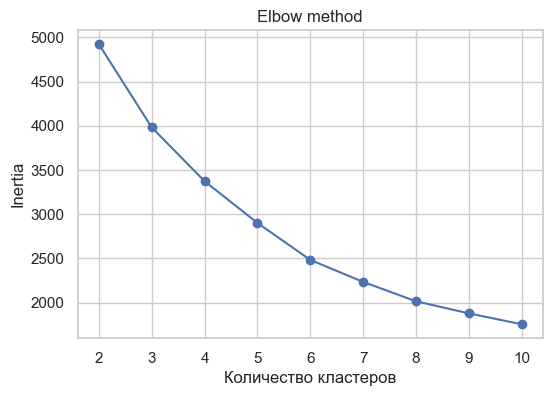

In [49]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(cluster_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

## Блок 4. Кластеризация KMeans

In [50]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_scaled)

df_model["cluster"] = clusters
display(df_model[["cluster"]].head())

,cluster
0,1
1,3
2,3
3,3
4,3


## Блок 5. Анализ кластеров

In [51]:
cluster_summary = (
    df_model.groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

display(cluster_summary)

,temperature,precipitation,lat,lon,hour,month,temp_lag_1,temp_roll_mean_24,temp_amplitude_day
cluster,,,,,,,,,
0,-3.20,0.16,55.04,82.93,11.49,1.0,-3.20,-3.12,12.95
1,4.05,4.56,57.22,39.96,13.15,1.0,3.90,0.99,13.27
2,5.07,0.12,57.72,34.19,18.95,1.0,4.67,1.40,12.71
3,-0.98,0.13,57.94,33.81,7.17,1.0,-0.74,1.37,12.70


## Блок 6. Визуализация кластеров через PCA

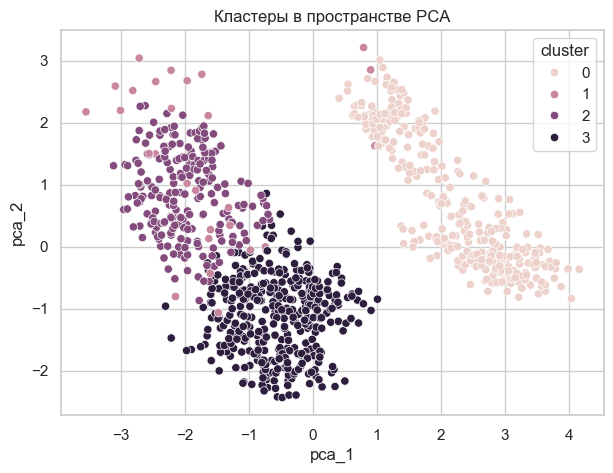

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_scaled)

plot_df = pd.DataFrame({
    "pca_1": cluster_pca[:, 0],
    "pca_2": cluster_pca[:, 1],
    "cluster": clusters
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="pca_1", y="pca_2", hue="cluster")
plt.title("Кластеры в пространстве PCA")
plt.show()

## Блок 7. Отображение кластеров на карте

In [ ]:
fig = px.scatter_map(
    df_model,
    lat="lat",
    lon="lon",
    color="cluster",
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()
fig.write_html("claster.html", include_plotlyjs='cdn')

## Блок 8. Альтернатива: DBSCAN

Хорошо, если хочешь искать плотные группы и выбросы.


In [54]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=10)
db_clusters = dbscan.fit_predict(cluster_scaled)

df_model["dbscan_cluster"] = db_clusters
display(df_model["dbscan_cluster"].value_counts())

dbscan_cluster
 8    265
-1    207
 0    173
 4    140
 1     57
 3     37
 2     25
 5     14
 6     12
 7      6
Name: count, dtype: int64

## Блок 9. Карта DBSCAN-кластеров

In [55]:
fig = px.scatter_map(
    df_model,
    lat="lat",
    lon="lon",
    color="dbscan_cluster",
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

## Блок 10. Дополнительная кластеризация: Agglomerative Clustering

Ещё один популярный алгоритм из `scikit-learn` — иерархическая кластеризация.

In [56]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters=4)
agg_clusters = agg_model.fit_predict(cluster_scaled)

df_model["agg_cluster"] = agg_clusters
display(df_model["agg_cluster"].value_counts())

agg_cluster
2    404
0    311
1    191
3     30
Name: count, dtype: int64

## Блок 11. Визуализация Agglomerative Clustering через PCA

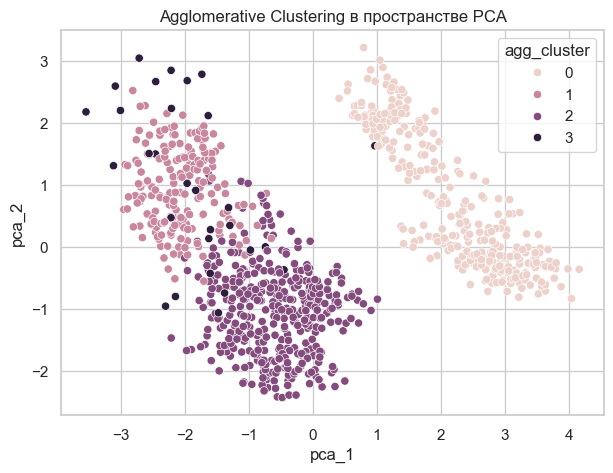

In [57]:
agg_plot_df = pd.DataFrame({
    "pca_1": cluster_pca[:, 0],
    "pca_2": cluster_pca[:, 1],
    "agg_cluster": agg_clusters
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=agg_plot_df, x="pca_1", y="pca_2", hue="agg_cluster")
plt.title("Agglomerative Clustering в пространстве PCA")
plt.show()

## Блок 12. Карта кластеров Agglomerative Clustering

In [58]:
fig = px.scatter_map(
    df_model,
    lat="lat",
    lon="lon",
    color="agg_cluster",
    hover_data=["temperature", "precipitation"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

# Практические замечания

Для этой задачи обычно удобно:

## Для карт
- `scatter_map` — если нужно показывать отдельные точки
- `density_mapbox` — если нужна плотность или интенсивность

## Для feature engineering
- час, месяц, weekday
- циклические признаки
- лаги 1 / 3 / 24
- rolling mean
- суточная амплитуда
- бинарный признак осадков

## Для кластеризации
- сначала `KMeans`
- потом, если нужны аномальные зоны или сложные формы групп, пробовать `DBSCAN`


# Важное замечание

Если эти признаки потом идут в модель прогноза:
- лаги должны строиться только из прошлого
- rolling тоже должен использовать только прошлые и текущие значения
- нельзя использовать будущие точки для признаков текущего момента
